<a href="https://colab.research.google.com/github/aaronbinoy/USELESS-PROJECTS-3.0/blob/main/BristleGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


          TOOTHBRUSH ANALYZER 9000™

Welcome to the world's least necessary toothbrush diagnostic lab.

Please upload a photo of your toothbrush.



Saving toothbrushnew.jpg to toothbrushnew (2).jpg

Image received: toothbrushnew (2).jpg


Initiating unnecessarily advanced toothbrush scan...


Locating suspicious bristles...
Measuring bristle life choices...
Checking whether this toothbrush still deserves employment...

Contacting the International Toothbrush Retirement Board...
Checking retirement eligibility...
Calculating pension for damaged bristles...

FINAL JUDGEMENT IN...

3...
2...
1...



           TOOTHBRUSH HEALTH REPORT

Detected Bristle Lines : 313
Dominant Orientation   : 0.30°
Bristle Disorder       : 59.38%
Average Deviation      : 29.71°
Frayed / Outlier Score : 47.12%

------------------------------------------------
FINAL WEAR SCORE       : 55.52/100
CONDITION              : MODERATELY WORN
------------------------------------------------

😬 TOOTHBRUSH STATUS: RETIREMENT APPROACHING

Official Diagnosis:
Your bristles are beginning to lose discipline.

Retirement Advice:
Start browsing for a replacement. The retirement paperwork has begun.


ORIGINAL TOOTHBRUSH


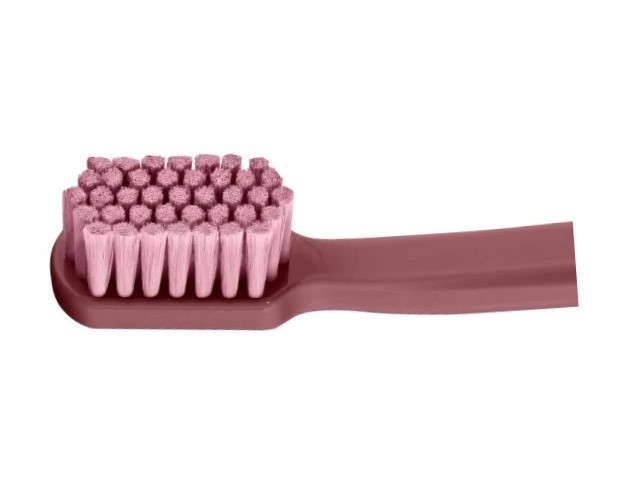


DETECTED BRISTLE REGION


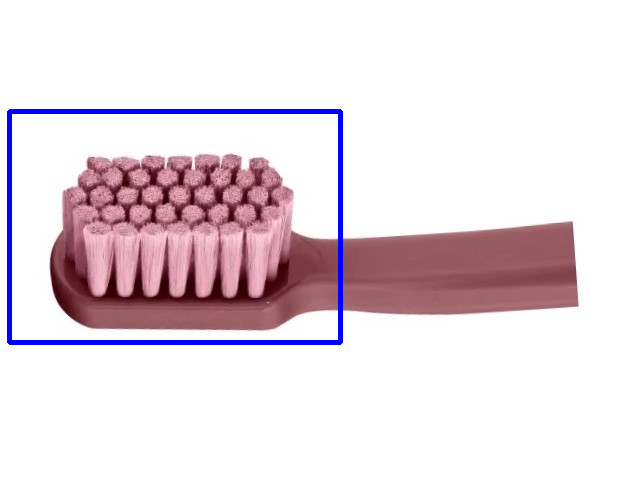


OPENCV EDGE DETECTION


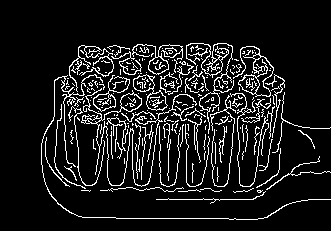


BRISTLE ANALYSIS
GREEN = relatively aligned
RED   = deviated / suspiciously chaotic


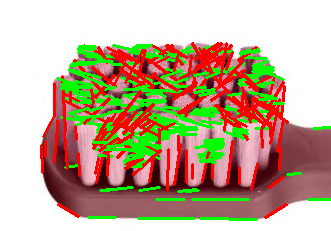


FINAL ANALYSIS RESULT


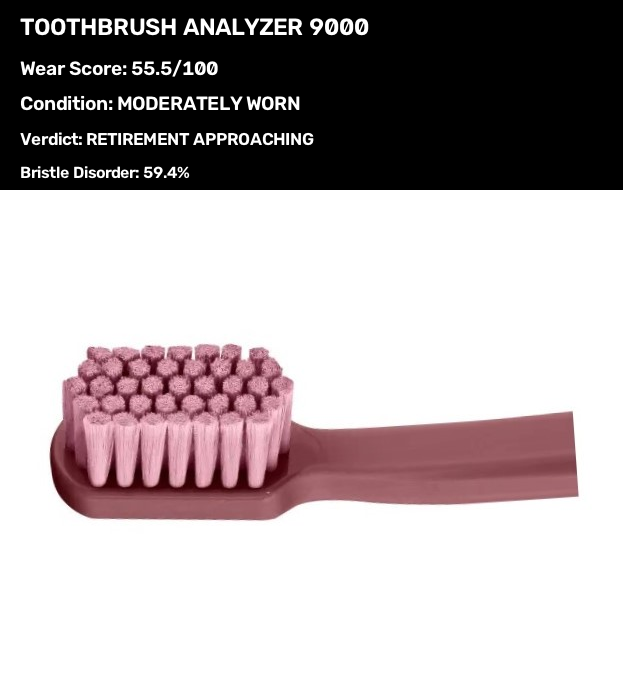


            ANALYSIS COMPLETE

Result saved as: toothbrush_analysis_result.jpg

Thank you for using Toothbrush Analyzer 9000™.
Your toothbrush may now return to active duty...
...or retirement.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import cv2
import numpy as np
import math
import time
import requests
from io import BytesIO

from google.colab import files
from google.colab.patches import cv2_imshow
from IPython.display import display, Image as IPImage
from PIL import Image


# ================================================================
# SETTINGS
# ================================================================

MAX_IMAGE_WIDTH = 1000

CANNY_LOW = 40
CANNY_HIGH = 130

HEALTHY_LIMIT = 32
WARNING_LIMIT = 58


# ================================================================
# FUN IMAGE URLS

SCANNING_IMAGE = "https://media.giphy.com/media/3o7TKtnuHOHHUjR38Y/giphy.gif"

HEALTHY_IMAGE = "https://media.giphy.com/media/l0MYt5jPR6QX5pnqM/giphy.gif"

WARNING_IMAGE = "https://media.giphy.com/media/ISOckXUybVfQ4/giphy.gif"

RETIRE_IMAGE = "https://media.giphy.com/media/14uQ3cOFteDaU/giphy.gif"


# ================================================================
# FUN IMAGE DISPLAY FUNCTION
# ================================================================

def show_fun_image(url, width=450):

    try:
        display(
            IPImage(
                url=url,
                width=width
            )
        )

    except Exception:
        pass


# ================================================================
# RESIZE IMAGE
# ================================================================

def resize_image(image, max_width=1000):

    h, w = image.shape[:2]

    if w <= max_width:
        return image

    scale = max_width / w

    new_width = int(w * scale)
    new_height = int(h * scale)

    return cv2.resize(
        image,
        (new_width, new_height),
        interpolation=cv2.INTER_AREA
    )


# ================================================================
# FIND BRISTLE REGION
# ================================================================

def find_bristle_region(gray):

    blur = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    edges = cv2.Canny(
        blur,
        CANNY_LOW,
        CANNY_HIGH
    )

    edge_binary = (
        edges > 0
    ).astype(np.float32)

    density = cv2.blur(
        edge_binary,
        (35, 35)
    )

    density_normalized = cv2.normalize(
        density,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    _, texture_mask = cv2.threshold(
        density_normalized,
        90,
        255,
        cv2.THRESH_BINARY
    )

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (25, 25)
    )

    texture_mask = cv2.morphologyEx(
        texture_mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    texture_mask = cv2.dilate(
        texture_mask,
        kernel,
        iterations=1
    )

    contours, _ = cv2.findContours(
        texture_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    h, w = gray.shape


    # ------------------------------------------------------------
    # FALLBACK
    # ------------------------------------------------------------

    if len(contours) == 0:

        x = int(w * 0.05)
        y = int(h * 0.08)

        bw = int(w * 0.60)
        bh = int(h * 0.75)

        return (
            x,
            y,
            bw,
            bh
        ), edges


    # ------------------------------------------------------------
    # FIND BEST HIGH-TEXTURE REGION
    # ------------------------------------------------------------

    best_score = -1
    best_box = None

    for contour in contours:

        x, y, bw, bh = cv2.boundingRect(
            contour
        )

        area = bw * bh

        if area < 500:
            continue

        roi_edges = edges[
            y:y + bh,
            x:x + bw
        ]

        edge_count = np.count_nonzero(
            roi_edges
        )

        score = edge_count * math.sqrt(
            area
        )

        if score > best_score:

            best_score = score

            best_box = (
                x,
                y,
                bw,
                bh
            )


    if best_box is None:

        x = int(w * 0.05)
        y = int(h * 0.08)

        bw = int(w * 0.60)
        bh = int(h * 0.75)

        return (
            x,
            y,
            bw,
            bh
        ), edges


    x, y, bw, bh = best_box


    # ------------------------------------------------------------
    # ADD PADDING
    # ------------------------------------------------------------

    pad_x = int(
        bw * 0.10
    )

    pad_y = int(
        bh * 0.15
    )

    x = max(
        0,
        x - pad_x
    )

    y = max(
        0,
        y - pad_y
    )

    bw = min(
        w - x,
        bw + 2 * pad_x
    )

    bh = min(
        h - y,
        bh + 2 * pad_y
    )

    return (
        x,
        y,
        bw,
        bh
    ), edges


# ================================================================
# ANALYZE TOOTHBRUSH
# ================================================================

def analyze_toothbrush(image):

    image = resize_image(
        image,
        MAX_IMAGE_WIDTH
    )

    original = image.copy()


    # ------------------------------------------------------------
    # FULL IMAGE TO GRAYSCALE
    # ------------------------------------------------------------

    gray_full = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # ------------------------------------------------------------
    # FIND BRISTLE REGION
    # ------------------------------------------------------------

    roi_box, full_edges = find_bristle_region(
        gray_full
    )

    x, y, w, h = roi_box


    roi = image[
        y:y + h,
        x:x + w
    ].copy()


    # ------------------------------------------------------------
    # PREPROCESS BRISTLE REGION
    # ------------------------------------------------------------

    gray = cv2.cvtColor(
        roi,
        cv2.COLOR_BGR2GRAY
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    gray = clahe.apply(
        gray
    )

    blurred = cv2.GaussianBlur(
        gray,
        (3, 3),
        0
    )

    edges = cv2.Canny(
        blurred,
        CANNY_LOW,
        CANNY_HIGH
    )


    # ------------------------------------------------------------
    # HOUGH LINE DETECTION
    # ------------------------------------------------------------

    min_line_length = max(
        10,
        int(
            min(w, h) * 0.06
        )
    )

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=15,
        minLineLength=min_line_length,
        maxLineGap=5
    )


    visual = roi.copy()

    angles = []
    lengths = []


    # ------------------------------------------------------------
    # EXTRACT LINE DATA
    # ------------------------------------------------------------

    if lines is not None:

        for line in lines:

            coords = np.array(
                line
            ).flatten()

            if len(coords) != 4:
                continue

            x1, y1, x2, y2 = coords

            dx = int(x2) - int(x1)
            dy = int(y2) - int(y1)

            length = np.sqrt(
                dx**2 +
                dy**2
            )

            if length < min_line_length:
                continue

            angle = np.degrees(
                np.arctan2(
                    dy,
                    dx
                )
            ) % 180

            angles.append(
                angle
            )

            lengths.append(
                length
            )


    # ------------------------------------------------------------
    # CHECK LINES
    # ------------------------------------------------------------

    if len(angles) < 5:

        return {
            "success": False,
            "original": original,
            "roi": roi,
            "edges": edges
        }


    angles = np.array(
        angles,
        dtype=np.float32
    )

    lengths = np.array(
        lengths,
        dtype=np.float32
    )


    # ============================================================
    # ORIENTATION DISORDER
    # ================================================================

    theta = np.radians(
        angles * 2
    )

    weights = lengths / np.sum(
        lengths
    )

    vector_x = np.sum(
        weights *
        np.cos(theta)
    )

    vector_y = np.sum(
        weights *
        np.sin(theta)
    )

    resultant = np.sqrt(
        vector_x**2 +
        vector_y**2
    )

    orientation_disorder = (
        1 - resultant
    ) * 100


    # ============================================================
    # DOMINANT ORIENTATION
    # ================================================================

    mean_theta = 0.5 * np.arctan2(
        vector_y,
        vector_x
    )

    dominant_angle = (
        np.degrees(
            mean_theta
        ) % 180
    )


    # ============================================================
    # AVERAGE DEVIATION
    # ================================================================

    differences = np.abs(
        angles -
        dominant_angle
    )

    differences = np.minimum(
        differences,
        180 - differences
    )

    weighted_deviation = np.average(
        differences,
        weights=lengths
    )

    deviation_score = np.clip(
        weighted_deviation / 45 * 100,
        0,
        100
    )


    # ============================================================
    # FRAYED / OUTLIER SCORE
    # ================================================================

    outliers = (
        differences > 25
    )

    outlier_score = (
        np.sum(
            lengths[outliers]
        )
        /
        np.sum(
            lengths
        )
    ) * 100


    # ============================================================
    # EDGE DENSITY
    # ================================================================

    edge_density = (
        np.count_nonzero(
            edges
        )
        /
        edges.size
    )

    edge_score = np.clip(
        edge_density * 250,
        0,
        100
    )


    # ============================================================
    # FINAL WEAR SCORE
    # ================================================================

    wear_score = (

        0.40 *
        orientation_disorder +

        0.30 *
        deviation_score +

        0.20 *
        outlier_score +

        0.10 *
        edge_score
    )

    wear_score = np.clip(
        wear_score,
        0,
        100
    )


    # ============================================================
    # DRAW DETECTED LINES
    # ================================================================

    if lines is not None:

        for line in lines:

            coords = np.array(
                line
            ).flatten()

            if len(coords) != 4:
                continue

            x1, y1, x2, y2 = coords

            dx = int(x2) - int(x1)
            dy = int(y2) - int(y1)

            length = np.sqrt(
                dx**2 +
                dy**2
            )

            if length < min_line_length:
                continue

            angle = np.degrees(
                np.arctan2(
                    dy,
                    dx
                )
            ) % 180

            difference = abs(
                angle -
                dominant_angle
            )

            difference = min(
                difference,
                180 - difference
            )


            # GREEN = normal
            # RED = frayed / deviated

            if difference > 25:

                color = (
                    0,
                    0,
                    255
                )

            else:

                color = (
                    0,
                    255,
                    0
                )


            cv2.line(
                visual,
                (
                    int(x1),
                    int(y1)
                ),
                (
                    int(x2),
                    int(y2)
                ),
                color,
                2
            )


    # ============================================================
    # CLASSIFICATION
    # ================================================================

    if wear_score < HEALTHY_LIMIT:

        condition = "HEALTHY"

        verdict = "GOOD TO GO"

        emoji = "😎"

        status = (
            "Your bristles are still behaving themselves."
        )

        retirement_advice = (
            "No retirement yet. "
            "This toothbrush still has a promising career."
        )


    elif wear_score < WARNING_LIMIT:

        condition = "MODERATELY WORN"

        verdict = "RETIREMENT APPROACHING"

        emoji = "😬"

        status = (
            "Your bristles are beginning to lose discipline."
        )

        retirement_advice = (
            "Start browsing for a replacement. "
            "The retirement paperwork has begun."
        )


    else:

        condition = "SEVERELY WORN"

        verdict = "RETIRE IMMEDIATELY"

        emoji = "💀"

        status = (
            "These bristles have officially abandoned formation."
        )

        retirement_advice = (
            "Buy a new toothbrush. "
            "This one has been reassigned to shoe-cleaning duty."
        )


    # ============================================================
    # DRAW BRISTLE REGION
    # ================================================================

    roi_display = original.copy()

    cv2.rectangle(
        roi_display,
        (
            int(x),
            int(y)
        ),
        (
            int(x + w),
            int(y + h)
        ),
        (
            255,
            0,
            0
        ),
        3
    )


    return {

        "success": True,

        "original": original,

        "roi": roi,

        "roi_display": roi_display,

        "edges": edges,

        "visual": visual,

        "wear_score":
            float(wear_score),

        "orientation_disorder":
            float(
                orientation_disorder
            ),

        "weighted_deviation":
            float(
                weighted_deviation
            ),

        "outlier_score":
            float(
                outlier_score
            ),

        "dominant_angle":
            float(
                dominant_angle
            ),

        "line_count":
            int(
                len(angles)
            ),

        "condition":
            condition,

        "verdict":
            verdict,

        "emoji":
            emoji,

        "status":
            status,

        "retirement_advice":
            retirement_advice
    }


# ================================================================
# PROGRAM START
# ================================================================

print()
print("================================================")
print("          TOOTHBRUSH ANALYZER 9000™")
print("================================================")
print()

print(
    "Welcome to the world's least necessary toothbrush diagnostic lab."
)

print()
print(
    "Please upload a photo of your toothbrush."
)

print()


# ================================================================
# UPLOAD IMAGE
# ================================================================

uploaded = files.upload()


if len(uploaded) == 0:

    raise Exception(
        "No image uploaded."
    )


IMAGE_PATH = list(
    uploaded.keys()
)[0]


print()
print(
    f"Image received: {IMAGE_PATH}"
)

print()


# ================================================================
# LOAD IMAGE
# ================================================================

image = cv2.imread(
    IMAGE_PATH
)


if image is None:

    raise Exception(
        "Could not open the uploaded image."
    )


# ================================================================
# ENTERTAINMENT - SCANNING
# ================================================================

print()
print(
    "Initiating unnecessarily advanced toothbrush scan..."
)

show_fun_image(
    SCANNING_IMAGE
)

time.sleep(2)


print(
    "Locating suspicious bristles..."
)

time.sleep(1)


print(
    "Measuring bristle life choices..."
)

time.sleep(1)


print(
    "Checking whether this toothbrush still deserves employment..."
)

time.sleep(1)


# ================================================================
# ANALYZE IMAGE
# ================================================================

result = analyze_toothbrush(
    image
)


# ================================================================
# DETECTION FAILED
# ================================================================

if not result["success"]:

    print()
    print(
        "SYSTEM CONFUSED."
    )

    print(
        "I could not detect enough bristle-like lines."
    )

    print()
    print(
        "Try another photo with:"
    )

    print(
        "- Better lighting"
    )

    print(
        "- Toothbrush head clearly visible"
    )

    print(
        "- Bristles in focus"
    )

    print(
        "- Simple background"
    )

    print()

    cv2_imshow(
        result["edges"]
    )

    raise SystemExit


# ================================================================
# DRAMATIC JUDGEMENT
# ================================================================

print()
print(
    "Contacting the International Toothbrush Retirement Board..."
)

time.sleep(1)

print(
    "Checking retirement eligibility..."
)

time.sleep(1)

print(
    "Calculating pension for damaged bristles..."
)

time.sleep(1)


print()
print(
    "FINAL JUDGEMENT IN..."
)

print()

print("3...")
time.sleep(1)

print("2...")
time.sleep(1)

print("1...")
time.sleep(1)


# ================================================================
# FUN VERDICT IMAGE
# ================================================================

if result["condition"] == "HEALTHY":

    show_fun_image(
        HEALTHY_IMAGE
    )

elif result["condition"] == "MODERATELY WORN":

    show_fun_image(
        WARNING_IMAGE
    )

else:

    show_fun_image(
        RETIRE_IMAGE
    )


# ================================================================
# PRINT HEALTH REPORT
# ================================================================

print()
print(
    "================================================"
)

print(
    "           TOOTHBRUSH HEALTH REPORT"
)

print(
    "================================================"
)

print()

print(
    f"Detected Bristle Lines : "
    f"{result['line_count']}"
)

print(
    f"Dominant Orientation   : "
    f"{result['dominant_angle']:.2f}°"
)

print(
    f"Bristle Disorder       : "
    f"{result['orientation_disorder']:.2f}%"
)

print(
    f"Average Deviation      : "
    f"{result['weighted_deviation']:.2f}°"
)

print(
    f"Frayed / Outlier Score : "
    f"{result['outlier_score']:.2f}%"
)

print()

print(
    "------------------------------------------------"
)

print(
    f"FINAL WEAR SCORE       : "
    f"{result['wear_score']:.2f}/100"
)

print(
    f"CONDITION              : "
    f"{result['condition']}"
)

print(
    "------------------------------------------------"
)

print()

print(
    f"{result['emoji']} TOOTHBRUSH STATUS: "
    f"{result['verdict']}"
)

print()

print(
    "Official Diagnosis:"
)

print(
    result["status"]
)

print()

print(
    "Retirement Advice:"
)

print(
    result["retirement_advice"]
)

print()

print(
    "================================================"
)


# ================================================================
# SHOW ORIGINAL IMAGE
# ================================================================

print()
print(
    "ORIGINAL TOOTHBRUSH"
)

cv2_imshow(
    result["original"]
)


# ================================================================
# SHOW DETECTED REGION
# ================================================================

print()
print(
    "DETECTED BRISTLE REGION"
)

cv2_imshow(
    result["roi_display"]
)


# ================================================================
# SHOW EDGES
# ================================================================

print()
print(
    "OPENCV EDGE DETECTION"
)

cv2_imshow(
    result["edges"]
)


# ================================================================
# SHOW BRISTLE ANALYSIS
# ================================================================

print()
print(
    "BRISTLE ANALYSIS"
)

print(
    "GREEN = relatively aligned"
)

print(
    "RED   = deviated / suspiciously chaotic"
)

cv2_imshow(
    result["visual"]
)


# ================================================================
# CREATE FINAL RESULT IMAGE
# ================================================================

def create_result_image(result):

    image = result[
        "original"
    ].copy()

    h, w = image.shape[:2]


    panel_height = 190


    panel = np.zeros(
        (
            panel_height,
            w,
            3
        ),
        dtype=np.uint8
    )


    cv2.putText(
        panel,
        "TOOTHBRUSH ANALYZER 9000",
        (
            20,
            35
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.80,
        (
            255,
            255,
            255
        ),
        2
    )


    cv2.putText(
        panel,
        f"Wear Score: {result['wear_score']:.1f}/100",
        (
            20,
            75
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (
            255,
            255,
            255
        ),
        2
    )


    cv2.putText(
        panel,
        f"Condition: {result['condition']}",
        (
            20,
            110
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (
            255,
            255,
            255
        ),
        2
    )


    cv2.putText(
        panel,
        f"Verdict: {result['verdict']}",
        (
            20,
            145
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.60,
        (
            255,
            255,
            255
        ),
        2
    )


    cv2.putText(
        panel,
        f"Bristle Disorder: {result['orientation_disorder']:.1f}%",
        (
            20,
            178
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (
            255,
            255,
            255
        ),
        2
    )


    output = np.vstack(
        [
            panel,
            image
        ]
    )

    return output


# ================================================================
# GENERATE FINAL IMAGE
# ================================================================

final_output = create_result_image(
    result
)


print()
print(
    "FINAL ANALYSIS RESULT"
)

cv2_imshow(
    final_output
)


# ================================================================
# SAVE RESULT
# ================================================================

OUTPUT_FILE = (
    "toothbrush_analysis_result.jpg"
)


cv2.imwrite(
    OUTPUT_FILE,
    final_output
)


print()
print(
    "================================================"
)

print(
    "            ANALYSIS COMPLETE"
)

print(
    "================================================"
)

print()

print(
    f"Result saved as: {OUTPUT_FILE}"
)

print()

print(
    "Thank you for using Toothbrush Analyzer 9000™."
)

print(
    "Your toothbrush may now return to active duty..."
)

print(
    "...or retirement."
)


# ================================================================
# DOWNLOAD RESULT
# ================================================================

files.download(
    OUTPUT_FILE
)